In [1]:
import time
import random
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Linear Search
def linear_search(arr, target):
    for i in arr:
        if i == target:
            return True
    return False

# Binary Search 
def binary_search(arr, target):
    low, high = 0, len(arr) - 1

    while low <= high:
        mid = (low + high) // 2

        if arr[mid] == target:
            return True
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1

    return False

In [ ]:
# Timing function
def avg_time(func, arr, target, repeat=5):
    total = 0
    for _ in range(repeat):
        start = time.perf_counter()
        func(arr, target)
        total += time.perf_counter() - start
    return total / repeat


In [ ]:

sizes = [100, 500, 1000, 5000, 10000]

results = []

for n in sizes:
    arr = random.sample(range(1, n * 10), n)

    arr_sorted = sorted(arr)

    best_target = arr[0]            
    avg_target = arr[n // 2]        
    worst_target = -1            

    # Linear Search Timings
    lin_best = avg_time(linear_search, arr, best_target)
    lin_avg = avg_time(linear_search, arr, avg_target)
    lin_worst = avg_time(linear_search, arr, worst_target)

    # Binary Search Timings
    bin_best = avg_time(binary_search, arr_sorted, arr_sorted[n // 2]) 
    bin_avg = avg_time(binary_search, arr_sorted, avg_target)
    bin_worst = avg_time(binary_search, arr_sorted, worst_target)

    results.append([n, lin_best, lin_avg, lin_worst, bin_best, bin_avg, bin_worst])

In [ ]:
df = pd.DataFrame(results, columns=[
    "n",
    "Linear Best", "Linear Avg", "Linear Worst",
    "Binary Best", "Binary Avg", "Binary Worst"
])

print("\nExecution Time Table:\n")
print(df)


Execution Time Table:

       n   Linear Best  Linear Avg  Linear Worst  Binary Best  Binary Avg  \
0    100  1.520012e-06    0.000005      0.000008     0.000004    0.000002   
1    500  6.599352e-07    0.000016      0.000028     0.000004    0.000003   
2   1000  9.800307e-07    0.000031      0.000073     0.000007    0.000005   
3   5000  1.799967e-06    0.000163      0.000339     0.000009    0.000009   
4  10000  1.839921e-06    0.000272      0.000686     0.000006    0.000004   

   Binary Worst  
0      0.000003  
1      0.000003  
2      0.000004  
3      0.000007  
4      0.000005  


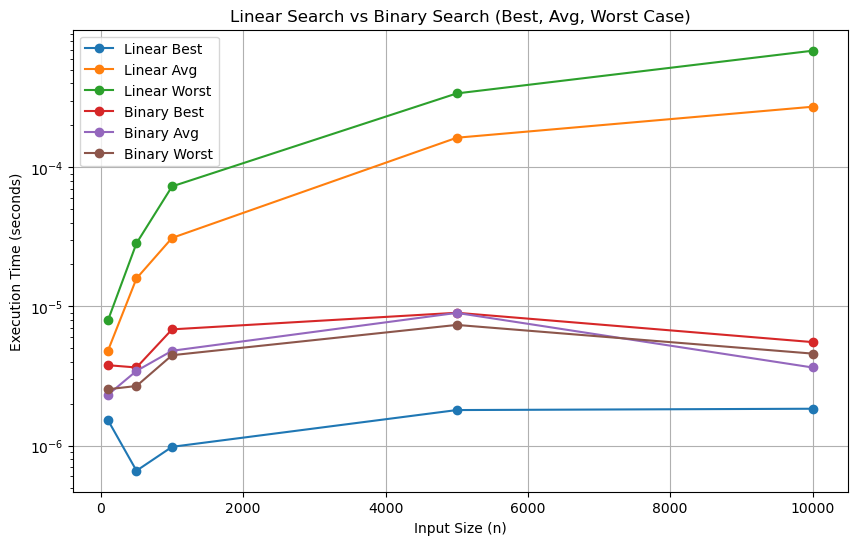

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(df["n"], df["Linear Best"], marker="o", label="Linear Best")
plt.plot(df["n"], df["Linear Avg"], marker="o", label="Linear Avg")
plt.plot(df["n"], df["Linear Worst"], marker="o", label="Linear Worst")

plt.plot(df["n"], df["Binary Best"], marker="o", label="Binary Best")
plt.plot(df["n"], df["Binary Avg"], marker="o", label="Binary Avg")
plt.plot(df["n"], df["Binary Worst"], marker="o", label="Binary Worst")

plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Linear Search vs Binary Search (Best, Avg, Worst Case)")
plt.legend()
plt.grid(True)

plt.yscale("log")
plt.show()